# 1/3 — Dataset Collection (49-dim features)

**Run this notebook first.** Produces `./data/state_space_datasetV5/dataset.npz`.

Successful trajectories only, collected from multiple checkpoints, full
500-step episodes including post-success frames. Each row is a 49-dim
feature vector: the raw 39-dim observation plus explicit hand→peg /
peg→goal offsets, distances, gripper openness, and a holding flag.

**Steps:** run cells top to bottom. Section 4 is a smoke test — check its
output before running the full collection in Section 5.

## 1. Imports and the shared feature builder

In [1]:
import gymnasium as gym
import metaworld
import numpy as np
import os, json, glob
from stable_baselines3 import SAC

In [2]:
# ============================================================
# SHARED FEATURE BUILDER — identical copy in all three notebooks.
# If you change it here, change it EVERYWHERE. A mismatch in column
# order fails silently: the model receives numbers in the wrong slots
# and returns plausible-looking garbage without raising.
# ============================================================
HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]
GRIPPER_CLOSED_THRESHOLD = 0.6
FEATURE_DIM = 49

def build_features(obs):
    """39-dim raw obs -> 49-dim feature vector.

    Columns:
       0-38  raw obs (unchanged)
      39-41  hand->peg vector
      42-44  peg->goal vector
         45  |hand->peg|
         46  |peg->goal|
         47  gripper openness
         48  holding flag (0/1)
    """
    obs = np.asarray(obs, dtype=np.float32)
    hand = obs[HAND_POS_IDX]
    peg  = obs[PEG_POS_IDX]
    goal = obs[GOAL_POS_IDX]
    gripper = obs[GRIPPER_IDX]

    hand_to_peg_vec = peg - hand
    peg_to_goal_vec = goal - peg
    hand_to_peg = np.linalg.norm(hand_to_peg_vec)
    peg_to_goal = np.linalg.norm(peg_to_goal_vec)
    holding = float(gripper < GRIPPER_CLOSED_THRESHOLD and hand_to_peg < 0.06)

    return np.concatenate([
        obs,
        hand_to_peg_vec,
        peg_to_goal_vec,
        [hand_to_peg, peg_to_goal, gripper, holding],
    ]).astype(np.float32)

In [3]:
TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

_probe = make_env(seed=0)
DT = getattr(_probe.unwrapped, "dt", _probe.unwrapped.model.opt.timestep)
RAW_OBS_DIM = _probe.observation_space.shape[0]
_probe.close()
print(f"DT={DT}, raw obs dim={RAW_OBS_DIM}, feature dim={FEATURE_DIM}")

DT=0.0125, raw obs dim=39, feature dim=49


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


## 2. Checkpoint selection

Deduplicated — an earlier version double-counted the final model because the glob returned `...final.zip` while `FINAL_CKPT` had no extension.

In [4]:
checkpoint_paths = sorted(
    glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
    key=lambda p: int("".join(ch for ch in os.path.basename(p) if ch.isdigit()) or 0))

selected_checkpoints = list(dict.fromkeys([
    checkpoint_paths[0],
    checkpoint_paths[len(checkpoint_paths)//2],
    checkpoint_paths[-1],
]))
print(f"{len(checkpoint_paths)} checkpoints found, using {len(selected_checkpoints)}:")
for p in selected_checkpoints:
    print("  ", os.path.basename(p))

8 checkpoints found, using 3:
   sac_peg_insert_final.zip
   sac_peg_insert_400000.zip
   sac_peg_insert_700000.zip


## 3. Collection function

`extra_frames_after_success=None` means episodes run the full 500 steps, so post-success states are represented. Truncating here was the cause of the earlier prediction divergence past the success point.

In [5]:
def collect_episode_state(model, env, deterministic=True, max_steps=500,
                           extra_frames_after_success=None):
    obs, _ = env.reset()
    obs_list = []
    success_step = None
    frames_since_success = 0
    for t in range(max_steps):
        obs_list.append(obs.copy())
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        if info.get(SUCCESS_KEY, 0) and success_step is None:
            success_step = t
        if success_step is not None and extra_frames_after_success is not None:
            frames_since_success += 1
            if frames_since_success >= extra_frames_after_success:
                break
        if terminated or truncated:
            break
    return obs_list, success_step

## 4. Smoke test — check this before Section 5

Confirms rollouts run full length and the feature builder produces 49 columns.

In [6]:
_m = SAC.load(selected_checkpoints[-1])
_env = make_env(seed=0)
_obs_list, _ss = collect_episode_state(_m, _env)
_env.close()

_feat = build_features(_obs_list[0])
print(f"success_step={_ss}, frames={len(_obs_list)}")
print(f"frames after success: {len(_obs_list) - (_ss + 1) if _ss is not None else 'n/a'}")
print(f"feature vector: {_feat.shape} (expect (49,))")
assert _feat.shape[0] == FEATURE_DIM, "feature dim mismatch"
print("OK — proceed to Section 5")

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


success_step=44, frames=500
frames after success: 455
feature vector: (49,) (expect (49,))
OK — proceed to Section 5


## 5. Full collection

In [7]:
EPISODES_PER_CHECKPOINT = 40

episodes = []
seed = 0
for ckpt in selected_checkpoints:
    ckpt_model = SAC.load(ckpt)
    tag = os.path.basename(ckpt)
    got, tries = 0, 0
    while got < EPISODES_PER_CHECKPOINT and tries < EPISODES_PER_CHECKPOINT * 4:
        env = make_env(seed=seed)
        obs_list, success_step = collect_episode_state(ckpt_model, env)
        env.close()
        tries += 1
        seed += 1
        if success_step is not None:
            episodes.append(dict(obs_list=obs_list, success_step=success_step,
                                   seed=seed, source_ckpt=tag))
            got += 1
    print(f"{tag}: {got}/{EPISODES_PER_CHECKPOINT} collected in {tries} attempts")

success_steps_all = [ep["success_step"] for ep in episodes]
print(f"\nTotal: {len(episodes)} episodes")
print(f"success_step: min={min(success_steps_all)}, max={max(success_steps_all)}, "
      f"mean={np.mean(success_steps_all):.1f}, std={np.std(success_steps_all):.1f}")

sac_peg_insert_final.zip: 40/40 collected in 40 attempts
sac_peg_insert_400000.zip: 40/40 collected in 50 attempts
sac_peg_insert_700000.zip: 40/40 collected in 40 attempts

Total: 120 episodes
success_step: min=41, max=255, mean=70.6, std=36.2


## 6. Build feature rows

In [8]:
records = []
for ep_idx, ep in enumerate(episodes):
    ss = ep["success_step"]
    for t, obs in enumerate(ep["obs_list"]):
        records.append(dict(
            episode_idx=ep_idx,
            frame_idx=t,
            steps_remaining=max(0, ss - t),   # post-success frames labelled 0
            features=build_features(obs),
        ))
print(f"Total rows: {len(records)}")
print(f"Avg frames/episode: {len(records)/len(episodes):.1f}  (expect ~500 if uncapped)")

Total rows: 60000
Avg frames/episode: 500.0  (expect ~500 if uncapped)


## 7. Save

In [9]:
OUTPUT_DIR = "./data/state_space_datasetV5"
os.makedirs(OUTPUT_DIR, exist_ok=True)

X = np.stack([r["features"] for r in records]).astype(np.float32)
y_steps = np.array([r["steps_remaining"] for r in records], dtype=np.float32)
episode_ids = np.array([r["episode_idx"] for r in records], dtype=np.int32)
holding_flags = X[:, 48]

np.savez(os.path.join(OUTPUT_DIR, "dataset.npz"),
         X=X, y_steps=y_steps, episode_ids=episode_ids, holding_flags=holding_flags)

summary = dict(
    total_rows=int(len(records)),
    total_episodes=int(len(episodes)),
    feature_dim=int(X.shape[1]),
    dt_sec=float(DT),
    sources_used=sorted(set(ep["source_ckpt"] for ep in episodes)),
    checkpoint_diversity=len(set(ep["source_ckpt"] for ep in episodes)) > 1,
    avg_frames_per_episode=round(len(records)/len(episodes), 1),
    success_step_min=int(min(success_steps_all)),
    success_step_max=int(max(success_steps_all)),
    success_step_std=float(np.std(success_steps_all)),
    holding_fraction=float(holding_flags.mean()),
)
with open(os.path.join(OUTPUT_DIR, "dataset_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "total_rows": 60000,
  "total_episodes": 120,
  "feature_dim": 49,
  "dt_sec": 0.0125,
  "sources_used": [
    "sac_peg_insert_400000.zip",
    "sac_peg_insert_700000.zip",
    "sac_peg_insert_final.zip"
  ],
  "checkpoint_diversity": true,
  "avg_frames_per_episode": 500.0,
  "success_step_min": 41,
  "success_step_max": 255,
  "success_step_std": 36.21843357401802,
  "holding_fraction": 0.5842666625976562
}


## 8. Validate the grasp signal

Expect one clean transition per episode, grasp frame roughly 20–65. Multiple transitions means the flag is flickering and `GRIPPER_CLOSED_THRESHOLD` needs tightening.

In [10]:
grasp_frames, multi, missing = [], 0, 0
for ep in np.unique(episode_ids):
    h = holding_flags[episode_ids == ep]
    onsets = np.where(np.diff(h) > 0)[0]
    if len(onsets) == 0:
        missing += 1
    else:
        grasp_frames.append(onsets[0])
        if len(onsets) > 1:
            multi += 1

grasp_frames = np.array(grasp_frames)
print(f"detected: {len(grasp_frames)}/{len(np.unique(episode_ids))}, "
      f"no grasp: {missing}, multiple transitions: {multi}")
print(f"grasp frame: mean={grasp_frames.mean():.1f}, "
      f"min={grasp_frames.min()}, max={grasp_frames.max()}")
print(f"holding=1 fraction: {holding_flags.mean():.1%}")

detected: 119/120, no grasp: 1, multiple transitions: 42
grasp frame: mean=31.5, min=21, max=63
holding=1 fraction: 58.4%


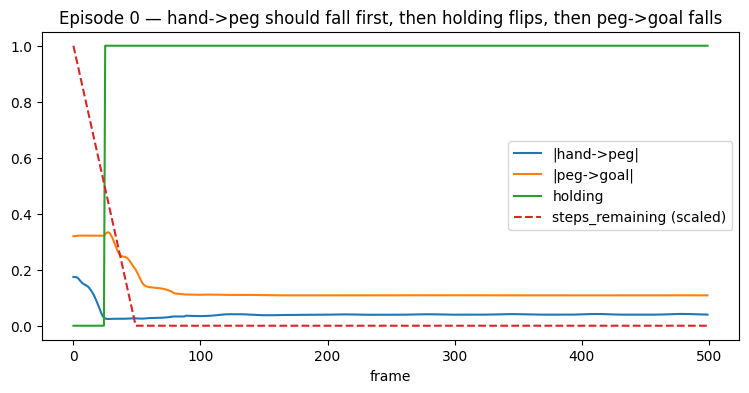

In [11]:
import matplotlib.pyplot as plt
m = episode_ids == 0
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(X[m, 45], label="|hand->peg|")
ax.plot(X[m, 46], label="|peg->goal|")
ax.plot(X[m, 48], label="holding")
ax.plot(y_steps[m] / max(y_steps[m].max(), 1), "--", label="steps_remaining (scaled)")
ax.set_xlabel("frame"); ax.legend()
ax.set_title("Episode 0 — hand->peg should fall first, then holding flips, then peg->goal falls")
plt.show()